In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
%config Inline.Backend.figure_format='svg'

In [2]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)
print(stoi)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [6]:
block_size = 3
X, Y = [], []
for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [7]:
X.shape, X.dtype,Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [8]:
C = torch.randn((27,2))
C

tensor([[-1.3607, -1.0826],
        [ 1.1790,  1.1689],
        [-0.4619, -1.4157],
        [ 0.6596, -1.0016],
        [ 0.4796, -0.6196],
        [-0.4425,  0.2214],
        [-0.7917, -0.0908],
        [ 1.2971,  1.5695],
        [ 0.9904,  0.0606],
        [-0.7409, -0.9497],
        [-0.1807, -1.3593],
        [ 0.6028,  0.6626],
        [-0.1729, -1.3023],
        [-0.0424, -0.9499],
        [ 1.2493, -0.5855],
        [ 2.1032,  0.4789],
        [-0.6526, -0.2309],
        [-0.8317, -0.1725],
        [-1.5326,  0.0822],
        [-0.1099, -0.5362],
        [-0.5576,  0.6016],
        [-0.1249,  1.9050],
        [ 1.0129,  1.5726],
        [-1.4397,  1.2004],
        [ 2.6447, -0.0667],
        [ 0.0922, -1.6497],
        [-0.1488,  1.2829]])

In [11]:
C[X].shape

torch.Size([32, 3, 2])

In [29]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [30]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [28]:
# emb = emb.view((X.shape[0],-1))
# emb.shape

torch.Size([32, 6])

In [21]:
# emb2 = torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]], 1)
# emb2.shape

torch.Size([32, 6])

In [23]:
# tt = emb-emb2

In [24]:
# tt

tensor([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0

In [34]:
 h = torch.tanh(emb.view((X.shape[0],-1)) @ W1 + b1)

In [35]:
h.shape

torch.Size([32, 100])

In [36]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)

In [37]:
logits = h @ W2 + b2

In [38]:
logits.shape

torch.Size([32, 27])

In [42]:
counts = logits.exp()
prob = counts / counts.sum(1,keepdim=True)

In [43]:
prob[0].sum()

tensor(1.)

In [45]:
loss = -prob[torch.arange(len(X)),Y].log().mean()

In [46]:
loss

tensor(14.8895)

In [106]:
block_size = 3
X, Y = [], []
for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [170]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10),generator=g,requires_grad=True)
W1 = torch.randn((30,200),generator=g,requires_grad=True)
b1 = torch.randn(200,generator=g,requires_grad=True)
W2 = torch.randn((200,27),generator=g,requires_grad=True)
b2 = torch.randn(27,generator=g,requires_grad=True)
parameters = [C, W1, b1, W2, b2]

In [171]:
sum(p.nelement() for p in parameters)

11897

In [135]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre


In [138]:
lri = []
lossi = []
stepi = []

for i in range(30000):

    ix = torch.randint(0,X.shape[0],(32,))
    
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Y[ix])
    # print(loss)
    for p in parameters:
        p.grad = None
    
    loss.backward()

    # lr = lrs[i]
    lr = 10**-1
    for p in parameters:
        p.data += -lr * p.grad

    # lri.append(lr)
    stepi.append(i)
    lossi.append(loss.item())
    
print(loss.item())

2.8903887271881104


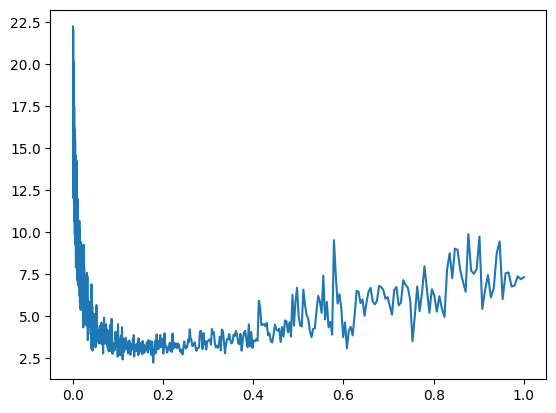

In [122]:
plt.plot(lri,lossi)

In [133]:
emb = C[X]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Y)
loss

tensor(2.3969, grad_fn=<NllLossBackward0>)

In [172]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182512, 3]) torch.Size([182512])
torch.Size([22860, 3]) torch.Size([22860])
torch.Size([22774, 3]) torch.Size([22774])


In [173]:
lri = []
lossi = []
stepi = []

for i in range(50000):

    ix = torch.randint(0,Xtr.shape[0],(32,))
    
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Ytr[ix])
    # print(loss)
    for p in parameters:
        p.grad = None
    
    loss.backward()

    # lr = lrs[i]
    lr = 10**-1
    for p in parameters:
        p.data += -lr * p.grad

    # lri.append(lr)
    stepi.append(i)
    lossi.append(loss.item())
    
print(loss.item())

2.567117929458618


In [174]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ydev)
loss

tensor(2.3659, grad_fn=<NllLossBackward0>)

In [175]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.3332, grad_fn=<NllLossBackward0>)

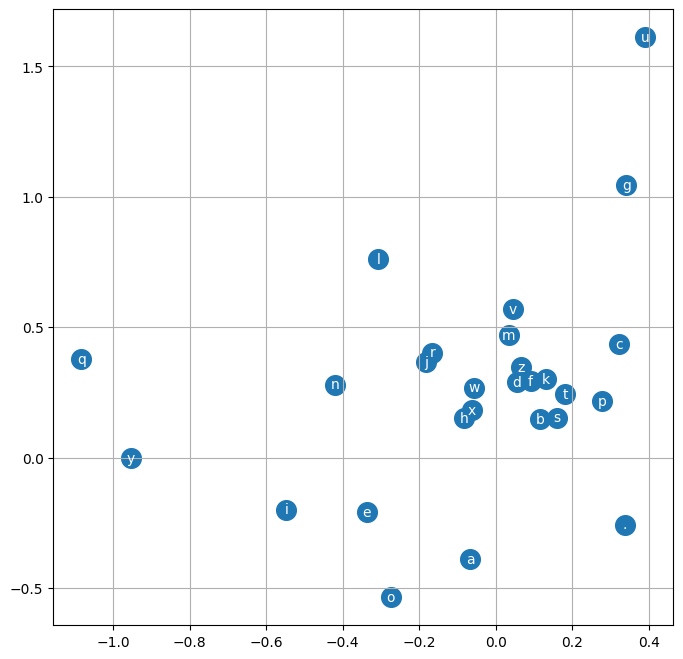

In [162]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data,s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(), itos[i], ha="center",va="center",color='white')
plt.grid('minor')    

In [183]:
g = torch.Generator().manual_seed(2147483647 + 10)
for i in range(20):

    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits,dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[j] for j in out))

mora.
mayannieen.
nohayal.
rensleigh.
rari.
adelen.
elinneni.
ren.
edennennana.
rellenoconel.
nosadbergiag.
jestin.
jewellenne.
cacen.
brence.
ryynn.
faent.
rayshuston.
mahja.
calynn.


In [181]:
context = [0] * block_size
torch.tensor(context).shape

torch.Size([3])